### Indoor

In [1]:
import sys

import matplotlib.pyplot as plt
import numpy as np

sys.path.append("../")
from datasets.dataloader import get_wireless_dataloader

dataloader = get_wireless_dataloader(
    "../datasets/outputs/conf_16x2_414u_5.0ghz_sbrRT_sc104.mat",
    drop_last=True,
)

In [2]:
data = next(iter(dataloader))
rx_position = data["rx_position"].squeeze()  # [3]
channel_matrix = data["channel_matrix"].squeeze()  # [tx_ant, rx_ant, 2]
aoa = data["aoa"][0]  # [2, num_paths], 2 for azimuth and elevation
path_loss = data["path_loss"]  # [1]
path_loss_per_ray = data["path_loss_per_ray"][0]  # [num_paths]

# verify shapes from dataloader
print("Dataloader shapes:")
print(f"RX position: {rx_position.shape}")
print(f"Channel matrix: {channel_matrix.shape}")
print(f"Path loss: {path_loss.shape}")
print(f"AoA: {aoa.shape}")
print(f"Path loss per ray: {path_loss_per_ray.shape}")

Dataloader shapes:
RX position: torch.Size([3])
Channel matrix: torch.Size([16, 2])
Path loss: torch.Size([1])
AoA: torch.Size([2, 14])
Path loss per ray: torch.Size([14])


In [3]:
min_paths = float("inf")
max_paths = 0

for batch in dataloader:
    aoa_data = batch["aoa"]
    if isinstance(aoa_data, (list, tuple)):
        if len(aoa_data) > 0 and len(aoa_data[0].shape) > 1:
            num_paths = aoa_data[0].shape[1]
        else:
            num_paths = 1
    else:
        num_paths = aoa_data.shape[1] if len(aoa_data.shape) > 1 else 1

    min_paths = min(min_paths, num_paths)
    max_paths = max(max_paths, num_paths)

print(f"Minimum number of paths: {min_paths}")
print(f"Maximum number of paths: {max_paths}")

Minimum number of paths: 1
Maximum number of paths: 22


Visualize $\textbf{H}$ as an Image $I$

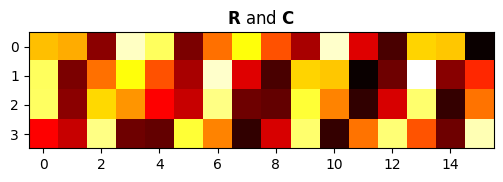

In [4]:
channel = channel_matrix.numpy()

fig, ax = plt.subplots(1, 1, figsize=(6, 4))

combined_image = np.hstack((channel.real, channel.imag))
ax.imshow(combined_image.transpose(), cmap="hot", interpolation="nearest")
ax.set_title(r"$\mathbf{R}$ and $\mathbf{C}$")

plt.show()

### Outdoor

In [5]:
dataloader = get_wireless_dataloader(
    "../datasets/outputs/iab_64x2_2268u_6.0ghz_sbrRT_sc312.mat",
    drop_last=True,
)

In [6]:
data = next(iter(dataloader))
rx_position = data["rx_position"].squeeze()  # [3]
channel_matrix = data["channel_matrix"].squeeze()  # [tx_ant, rx_ant, 2]
aoa = data["aoa"][0]  # [2, num_paths], 2 for azimuth and elevation
path_loss = data["path_loss"]  # [1]
path_loss_per_ray = data["path_loss_per_ray"][0]  # [num_paths]

# verify shapes from dataloader
print("Dataloader shapes:")
print(f"RX position: {rx_position.shape}")
print(f"Channel matrix: {channel_matrix.shape}")
print(f"Path loss: {path_loss.shape}")
print(f"AoA: {aoa.shape}")
print(f"Path loss per ray: {path_loss_per_ray.shape}")

Dataloader shapes:
RX position: torch.Size([3])
Channel matrix: torch.Size([64, 2])
Path loss: torch.Size([1])
AoA: torch.Size([2, 30])
Path loss per ray: torch.Size([30])


In [7]:
min_paths = float("inf")
max_paths = 0

for batch in dataloader:
    aoa_data = batch["aoa"]
    if isinstance(aoa_data, (list, tuple)):
        if len(aoa_data) > 0 and len(aoa_data[0].shape) > 1:
            num_paths = aoa_data[0].shape[1]
        else:
            num_paths = 1
    else:
        num_paths = aoa_data.shape[1] if len(aoa_data.shape) > 1 else 1

    min_paths = min(min_paths, num_paths)
    max_paths = max(max_paths, num_paths)

print(f"Minimum number of paths: {min_paths}")
print(f"Maximum number of paths: {max_paths}")

Minimum number of paths: 1
Maximum number of paths: 30


Visualize $\textbf{H}$ as an Image $I$

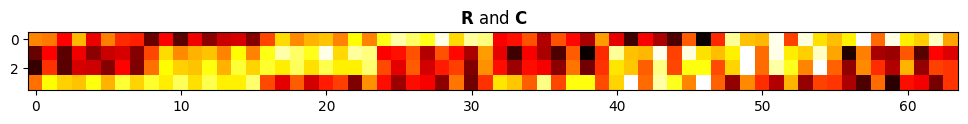

In [8]:
channel = channel_matrix.numpy()

fig, ax = plt.subplots(1, 1, figsize=(12, 4))

combined_image = np.hstack((channel.real, channel.imag))
ax.imshow(combined_image.transpose(), cmap="hot", interpolation="nearest")
ax.set_title(r"$\mathbf{R}$ and $\mathbf{C}$")

plt.show()